# CBIM Problem Canvas

| **Canvas Element** | **Answer** |
|---|---|
| **Situation (S)** | A regional retail chain operates **12 stores across Andhra Pradesh** and has six months of transaction data from **January to June 2026**. Historical sales data is available in a CSV file, while the latest 7-day sales data is available through a simulated JSON API response. |
| **Complication (C)** | The Head of Retail Operations does not have a clear, data-driven view of **which stores are underperforming, which categories are declining, when sales are strongest or weakest, and whether unusual store-week performance needs investigation**. The weekly analysis also needs to be refreshed automatically instead of being manually repeated. |
| **Question (Q)** | **Which stores and product categories should receive attention for Q3 promotional planning, what sales patterns or anomalies require investigation, and how can the latest weekly sales be automatically compared with the historical baseline?** |
| **SSOT** | **Part 1:** The historical CSV is the source of truth for the January–June 2026 baseline. **Part 2:** The weekly JSON API response is the source of truth for the latest 7-day sales signal. The JSON results are compared against the historical CSV baseline to identify meaningful changes and alerts. |
| **Success Definition** | **Part 1:** Deliver all required store, category, day-of-week, monthly and anomaly analyses and produce **one specific, data-backed business recommendation**. **Part 2:** Successfully process the **4,291 weekly records**, catch **all 3 intentional data-quality issues**, calculate the required weekly outputs, and generate the weekly summary successfully. |
| **Primary Stakeholder** | **Head of Retail Operations**, who needs to make **Q3 promotional-spend decisions** and review weekly sales performance **every Monday morning**. |

# PART 1 — Retail Sales Pulse: Exploratory Data Analysis

# 5.1 — Load and inspect the CSV

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
df = pd.read_csv("/Users/pinnamanenisaisubhash/Downloads/MUC01_Retail_Sales_Dataset.csv")

In [69]:
df.shape

(107836, 10)

In [70]:
df.head()

,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct
0,TXN000001,2026-01-01,S01,Vijayawada,Electronics,Smart TV,2,3075.46,5843.37,5
1,TXN000002,2026-01-01,S01,Vijayawada,Electronics,Laptop,1,11598.06,11598.06,0
2,TXN000003,2026-01-01,S01,Vijayawada,Electronics,Tablet,3,5738.37,15493.60,10
3,TXN000004,2026-01-01,S01,Vijayawada,Electronics,Smart TV,3,3281.28,9351.65,5
4,TXN000005,2026-01-01,S01,Vijayawada,Apparel,Jeans,1,1917.14,1917.14,0


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107836 entries, 0 to 107835
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   transaction_id  107836 non-null  object 
 1   date            107836 non-null  object 
 2   store_id        107836 non-null  object 
 3   store_city      107836 non-null  object 
 4   category        107836 non-null  object 
 5   product_name    107836 non-null  object 
 6   units_sold      107836 non-null  int64  
 7   unit_price      107836 non-null  float64
 8   revenue         107836 non-null  float64
 9   discount_pct    107836 non-null  int64  
dtypes: float64(2), int64(2), object(6)
memory usage: 8.2+ MB


In [72]:
df.isnull().sum()

transaction_id    0
date              0
store_id          0
store_city        0
category          0
product_name      0
units_sold        0
unit_price        0
revenue           0
discount_pct      0
dtype: int64

In [73]:
df.describe()

,units_sold,unit_price,revenue,discount_pct
count,107836.000000,107836.000000,107836.000000,107836.000000
mean,2.583488,1778.097787,4263.920924,7.228152
std,1.471616,5053.631792,14243.244169,6.730445
min,1.000000,50.020000,40.040000,0.000000
25%,1.000000,274.827500,467.772500,0.000000
50%,2.000000,488.450000,1034.615000,5.000000
75%,3.000000,1039.522500,2473.335000,10.000000
max,13.000000,44990.140000,355090.880000,20.000000


The dataset contains 107,836 transactions and 10 columns. There are no null values.

The descriptive statistics show that the average revenue per transaction is about ₹4,263.92, while the median is only about ₹1,034.62 this means that overall revenue may depend heavily on occasional large purchases, so the business should understand which products, stores or customer transactions are responsible for these high-value sales.

The maximum transaction revenue is about ₹355,090.88, which is much higher than the average. This  represent a high-value purchase, but these transactions could be investigated by store, category, and product to understand whether they represent normal premium purchases or unusual transactions."

# 5.2  Revenue by store


In this step, I calculate the total revenue generated by each store during the six-month period. I then rank the stores from highest to lowest revenue and visualize the results using a horizontal bar chart.

In [74]:
# Calculate total revenue per store
store_revenue = df.groupby("store_id")["revenue"].sum()
store_revenue = store_revenue.sort_values(ascending=False)

store_revenue

store_id
S01    59055493.38
S03    53175162.00
S07    48537659.56
S06    44969840.50
S02    42069856.33
S04    41379797.16
S08    35032561.12
S09    33452441.09
S11    32780138.71
S05    25157347.02
S10    22217399.05
S12    21976480.86
Name: revenue, dtype: float64

In [75]:
colors = []

for i in range(len(store_revenue)):
    if i < 3:
        colors.append("green")
    elif i >= len(store_revenue) - 3:
        colors.append("Sky Blue")
    else:
        colors.append("Orange Red")

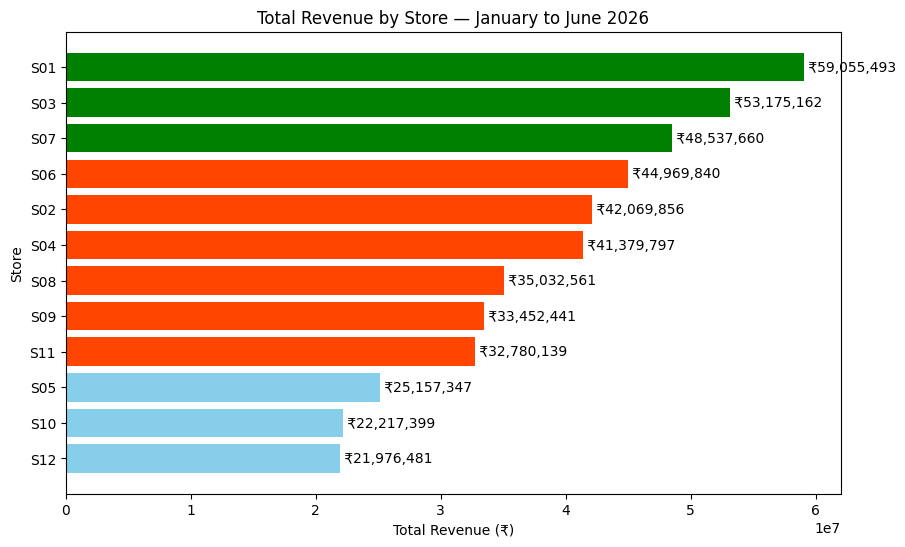

In [76]:
plt.figure(figsize=(10, 6))

bars = plt.barh(store_revenue.index, store_revenue.values, color=[c.replace('Orange Red', 'orangered').replace('Sky Blue', 'skyblue') for c in colors])

plt.xlabel("Total Revenue (₹)")
plt.ylabel("Store")
plt.title("Total Revenue by Store — January to June 2026")

plt.gca().invert_yaxis()
for bar in bars:
    value = bar.get_width()
    plt.text(value, bar.get_y() + bar.get_height()/2,
             f" ₹{value:,.0f}",
             va="center")

plt.show()

In [77]:
top_3_stores = store_revenue.head(3)

bottom_3_stores = store_revenue.tail(3)

print("Top 3 Stores:")
print(top_3_stores)

print("Bottom 3 Stores:")
print(bottom_3_stores)

Top 3 Stores:
store_id
S01    59055493.38
S03    53175162.00
S07    48537659.56
Name: revenue, dtype: float64
Bottom 3 Stores:
store_id
S05    25157347.02
S10    22217399.05
S12    21976480.86
Name: revenue, dtype: float64


### Business Interpretation

S01 (Vijayawada) is the highest-revenue store with about ₹59.1 million, while S12 (Kakinada) is the lowest with about ₹22.0 million, showing a significant performance gap between stores. The operations team should investigate what is driving the stronger performance of the top stores and whether the bottom stores have issues related to demand, product availability, pricing, or local competition. 
then team decide where additional promotional support or operational improvements are most needed.

# 5.3 — Category Performance Over Time


In this step, I analyze monthly revenue for each product category from January to June 2026. The purpose is to identify categories with declining trends and categories with relatively stable revenue performance over time.

In [78]:
# Extract month from date
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.to_period("M").astype(str)

In [79]:
# Group revenue by month and category
Revenue_category_monthly = (df.groupby(["month", "category"])["revenue"].sum().reset_index())
print(Revenue_category_monthly)

      month        category      revenue
0   2026-01         Apparel  10049916.78
1   2026-01     Electronics  45686596.63
2   2026-01         Grocery   7307011.34
3   2026-01  Home & Kitchen  15130871.54
4   2026-01   Personal Care   6593734.81
5   2026-02         Apparel   9510938.10
6   2026-02     Electronics  38988602.50
7   2026-02         Grocery   6534957.35
8   2026-02  Home & Kitchen  13006413.31
9   2026-02   Personal Care   5792754.97
10  2026-03         Apparel  11540439.47
11  2026-03     Electronics  40846509.47
12  2026-03         Grocery   7132787.06
13  2026-03  Home & Kitchen  14362119.50
14  2026-03   Personal Care   6808029.34
15  2026-04         Apparel  11681806.66
16  2026-04     Electronics  37092265.09
17  2026-04         Grocery   7047399.58
18  2026-04  Home & Kitchen  13431147.66
19  2026-04   Personal Care   6417868.13
20  2026-05         Apparel  13219535.79
21  2026-05     Electronics  34226926.43
22  2026-05         Grocery   7232706.20
23  2026-05  Hom

In [80]:
# Convert into a table for plotting
category_monthly = Revenue_category_monthly

category_pivot = category_monthly.pivot(
    index="month",
    columns="category",
    values="revenue"
)


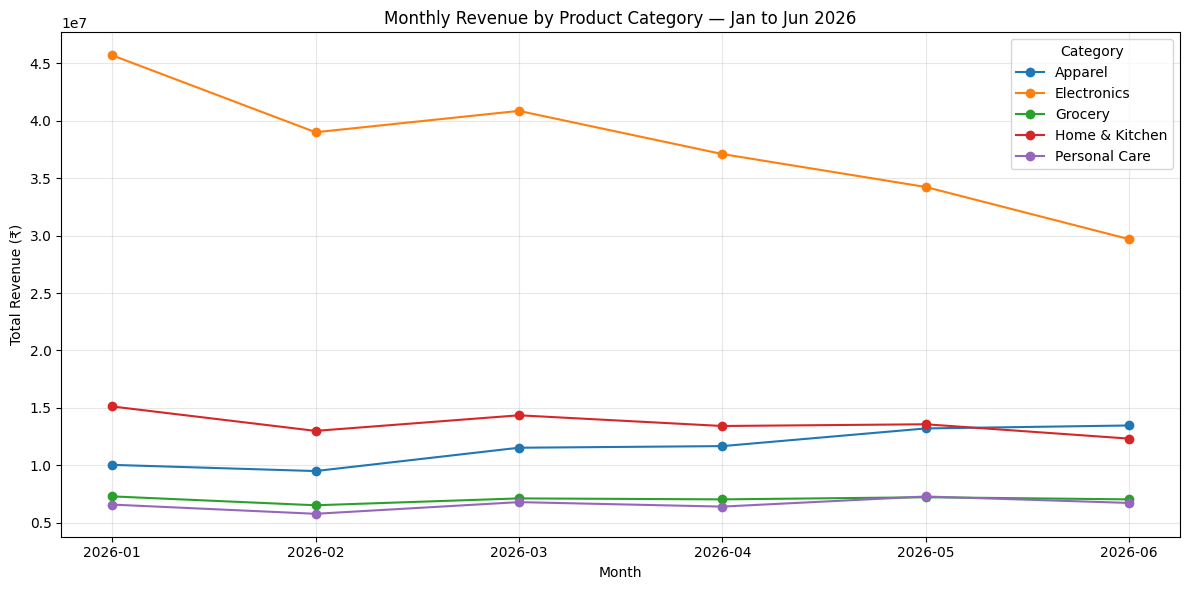

In [81]:
# Plotting line chart for all categories

plt.figure(figsize=(12, 6))

for category in category_pivot.columns:
    plt.plot(
        category_pivot.index,
        category_pivot[category],
        marker="o",
        label=category
    )
plt.title("Monthly Revenue by Product Category — Jan to Jun 2026")
plt.xlabel("Month")
plt.ylabel("Total Revenue (₹)")
plt.legend(title="Category")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [82]:
#identify the steepest decline
category_change = (category_pivot.iloc[-1]- category_pivot.iloc[0])

category_change.sort_values()

category
Electronics      -15999771.82
Home & Kitchen    -2797588.47
Grocery            -259292.11
Personal Care       143619.31
Apparel            3427036.10
dtype: float64

In [83]:
category_pct_change = ((category_pivot.iloc[-1] -category_pivot.iloc[0])/ category_pivot.iloc[0]) * 100

category_pct_change.sort_values()

category
Electronics      -35.020713
Home & Kitchen   -18.489275
Grocery           -3.548538
Personal Care      2.178118
Apparel           34.100144
dtype: float64

In [84]:
# identify the most stable category
category_std = category_pivot.std()

category_std.sort_values()

category
Grocery           2.726059e+05
Personal Care     4.969814e+05
Home & Kitchen    9.899583e+05
Apparel           1.607520e+06
Electronics       5.513101e+06
dtype: float64

In [85]:
steepest_decline = category_pct_change.idxmin()
steepest_decline_pct = category_pct_change.min()

category_cv = (category_std / category_pivot.mean()) * 100
most_stable = category_cv.idxmin()
most_stable_cv = category_cv.min()

print("Steepest declining category:", steepest_decline)
print(f"Percentage change: {steepest_decline_pct:.2f}%")

print("\nMost stable category:", most_stable)
print(f"Coefficient of variation: {most_stable_cv:.2f}")

Steepest declining category: Electronics
Percentage change: -35.02%

Most stable category: Grocery
Coefficient of variation: 3.87


### Business Interpretation

Electronics shows the steepest decline, falling by approximately **35.02% from January to June**. This may indicate weakening demand, pricing pressure, inventory issues, or increased competitor activity, so the operations team should investigate which electronics products and stores are contributing most to the decline. Grocery is the most stable category, suggesting that it provides a relatively predictable revenue base.


# 5.4 — Day-of-week and Monthly Patterns


In this step, I analyze revenue patterns by day of the week and by month. The objective is to identify the best and worst performing days and months and use these patterns to recommend when a flash promotion could be most effective.

In [86]:
df["day_of_week"] = df["date"].dt.day_name()

In [87]:
# Calculate total revenue for each date
daily_revenue = (df.groupby(["date", "day_of_week"])["revenue"].sum().reset_index())
daily_revenue

,date,day_of_week,revenue
0,2026-01-01,Thursday,1811086.82
1,2026-01-02,Friday,2846032.80
2,2026-01-03,Saturday,4214219.34
3,2026-01-04,Sunday,3122804.05
4,2026-01-05,Monday,1935902.72
...,...,...,...
176,2026-06-26,Friday,2132585.36
177,2026-06-27,Saturday,3337874.15
178,2026-06-28,Sunday,2411911.36
179,2026-06-29,Monday,1633487.33


In [88]:
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

In [89]:
# Calculate average daily revenue by day of week
revenue_by_day = (daily_revenue.groupby("day_of_week")["revenue"].mean().reindex(day_order))
revenue_by_day

day_of_week
Monday       2.012141e+06
Tuesday      2.054130e+06
Wednesday    2.228117e+06
Thursday     2.245493e+06
Friday       2.623612e+06
Saturday     3.523605e+06
Sunday       3.083375e+06
Name: revenue, dtype: float64

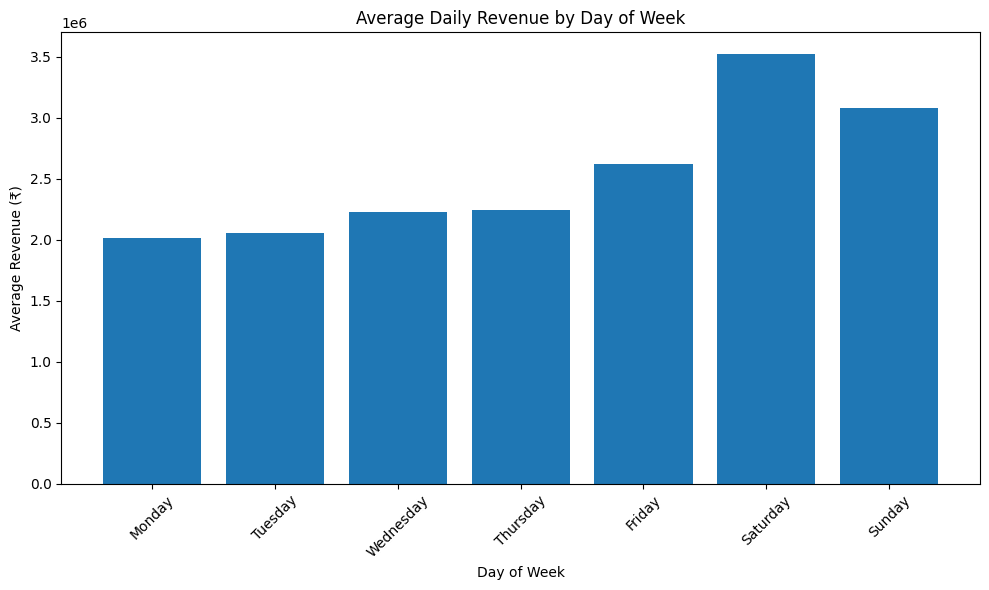

In [90]:
plt.figure(figsize=(10, 6))

plt.bar(revenue_by_day.index,revenue_by_day.values)

plt.xlabel("Day of Week")
plt.ylabel("Average Revenue (₹)")
plt.title("Average Daily Revenue by Day of Week")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [91]:
revenue_by_day = (daily_revenue.groupby("day_of_week")["revenue"].mean().reindex(day_order))
best_day = revenue_by_day.max()

worst_day =revenue_by_day.idxmin()
worst_day_revenue =revenue_by_day.min()

print("Best performing day:", best_day)
best_day_revenue = revenue_by_day.max()
print(f"Average revenue: ₹{best_day_revenue:,.2f}")

print("\nWorst performing day:", worst_day)
print(f"Average revenue: ₹{worst_day_revenue:,.2f}")

Best performing day: 3523605.445
Average revenue: ₹3,523,605.44

Worst performing day: Monday
Average revenue: ₹2,012,140.96


In [92]:
# calculate total revenue by month
df["month"] = df["date"].dt.to_period("M")

In [93]:
monthly_revenue = df.groupby("month")["revenue"].sum()
print(monthly_revenue)

month
2026-01    84768131.10
2026-02    73833666.23
2026-03    80689884.84
2026-04    75670487.12
2026-05    75559873.38
2026-06    69282134.11
Freq: M, Name: revenue, dtype: float64


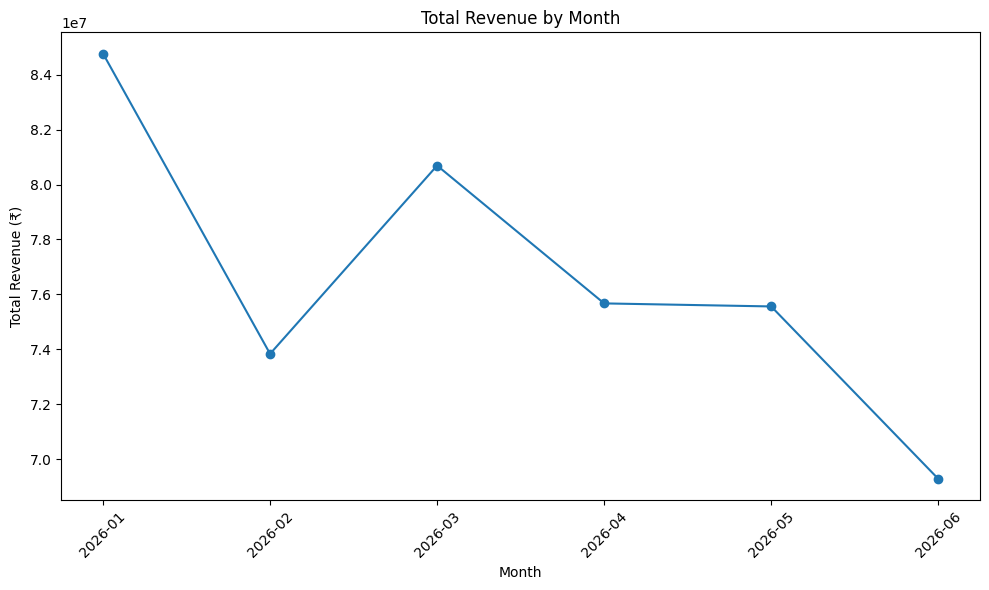

In [94]:
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Total Revenue (₹)")
plt.title("Total Revenue by Month")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [95]:
best_month = monthly_revenue.idxmax()
best_month_revenue = monthly_revenue.max()

worst_month = monthly_revenue.idxmin()
worst_month_revenue = monthly_revenue.min()

print("Best performing month:", best_month)
print(f"Total revenue: ₹{best_month_revenue:,.2f}")

print("\nWorst performing month:", worst_month)
print(f"Total revenue: ₹{worst_month_revenue:,.2f}")

Best performing month: 2026-01
Total revenue: ₹84,768,131.10

Worst performing month: 2026-06
Total revenue: ₹69,282,134.11


### Flash Promotion Recommendation

Saturday has the highest average daily revenue at approximately **₹35.24 lakh**, while Monday has the lowest at approximately **₹20.12 lakh**.  I would recommend **testing a flash promotion on Monday** to increase sales demand on the weakest trading day, while using Saturday as a benchmark because demand is already strong. January was the strongest month at approximately **₹8.48 crore**, while June was the weakest at approximately **₹6.93 crore**, so the operations team should also investigate whether seasonal or demand changes are affecting sales.

# 5.5 — Anomaly Identification

calculate weekly revenue per store. Flag any store-week combinations where revenue falls more than 2 standard deviations below that store's own average weekly revenue. List the flagged combinations and for each one, suggest one possible business reason — supply disruption, local event, pricing issue, competitor activity. Practising reasoned hypothesis formation is the point.

In [96]:
# Make sure date is datetime
df["date"] = pd.to_datetime(df["date"])

In [97]:
#Create the week
df["week"] = df["date"].dt.to_period("W").apply(lambda x: x.start_time)

In [98]:
#Calculate weekly revenue for each store
weekly_store_revenue = (df.groupby(["store_id", "week"])["revenue"].sum().reset_index())


In [99]:

# Count number of days available in each week
days_per_week = (df.groupby("week")["date"].nunique().reset_index(name="days"))

# Keep only complete 7-day weeks
complete_weeks = days_per_week[days_per_week["days"] == 7]["week"]

weekly_store_revenue = weekly_store_revenue[weekly_store_revenue["week"].isin(complete_weeks)].copy()

weekly_store_revenue.head()

,store_id,week,revenue
1,S01,2026-01-05,2350618.81
2,S01,2026-01-12,2316840.47
3,S01,2026-01-19,2579278.37
4,S01,2026-01-26,2000527.75
5,S01,2026-02-02,2178007.52


In [100]:
#Calculate each store's average and standard deviation
store_stats = (weekly_store_revenue.groupby("store_id")["revenue"].agg(["mean", "std"]).reset_index())

store_stats

,store_id,mean,std
0,S01,2.302970e+06,293995.108575
1,S02,1.627619e+06,226809.226710
2,S03,2.049074e+06,269100.872352
3,S04,1.598816e+06,228635.581011
4,S05,9.774069e+05,127113.547805
5,S06,1.741919e+06,267725.531989
6,S07,1.876781e+06,308258.987633
7,S08,1.334241e+06,177407.496556
8,S09,1.290915e+06,169966.407685
9,S10,8.671293e+05,163809.391223


Lower threshold = Mean − 2 × Standard Deviation

In [101]:
#Calculate the anomaly threshold
store_stats["lower_threshold"] = (store_stats["mean"] - 2 * store_stats["std"])

store_stats

,store_id,mean,std,lower_threshold
0,S01,2.302970e+06,293995.108575,1.714980e+06
1,S02,1.627619e+06,226809.226710,1.174000e+06
2,S03,2.049074e+06,269100.872352,1.510872e+06
3,S04,1.598816e+06,228635.581011,1.141545e+06
4,S05,9.774069e+05,127113.547805,7.231798e+05
5,S06,1.741919e+06,267725.531989,1.206467e+06
6,S07,1.876781e+06,308258.987633,1.260263e+06
7,S08,1.334241e+06,177407.496556,9.794262e+05
8,S09,1.290915e+06,169966.407685,9.509819e+05
9,S10,8.671293e+05,163809.391223,5.395105e+05


In [102]:
#Add the threshold to every store-week
weekly_store_revenue = weekly_store_revenue.merge(store_stats,on="store_id", how="left")

In [103]:
#Flag the anomalies
weekly_store_revenue["is_anomaly"] = (weekly_store_revenue["revenue"]< weekly_store_revenue["lower_threshold"])

In [104]:
anomalies = weekly_store_revenue[weekly_store_revenue["is_anomaly"]].copy()
anomalies[["store_id","week","revenue","mean","std", "lower_threshold"]]

,store_id,week,revenue,mean,std,lower_threshold
44,S02,2026-05-18,1173289.36,1.627619e+06,226809.226710,1.174000e+06
97,S04,2026-06-08,1137480.32,1.598816e+06,228635.581011,1.141545e+06
105,S05,2026-02-09,655732.19,9.774069e+05,127113.547805,7.231798e+05
238,S10,2026-04-06,505536.54,8.671293e+05,163809.391223,5.395105e+05


In [105]:
anomalies = anomalies.loc[:, ~anomalies.columns.duplicated()].copy()

anomalies["possible_reason"] = (
    "Possible supply disruption, local event, pricing issue, "
    "or competitor activity; further investigation is required.")

display(anomalies)

,store_id,week,revenue,mean,std,lower_threshold,is_anomaly,possible_reason
44,S02,2026-05-18,1173289.36,1.627619e+06,226809.226710,1.174000e+06,True,"Possible supply disruption, local event, prici..."
97,S04,2026-06-08,1137480.32,1.598816e+06,228635.581011,1.141545e+06,True,"Possible supply disruption, local event, prici..."
105,S05,2026-02-09,655732.19,9.774069e+05,127113.547805,7.231798e+05,True,"Possible supply disruption, local event, prici..."
238,S10,2026-04-06,505536.54,8.671293e+05,163809.391223,5.395105e+05,True,"Possible supply disruption, local event, prici..."


## Business interpretation:
The flagged store-week combinations represent periods where revenue was more than two standard deviations below the store's normal weekly revenue. These are treated as potential warning signals rather than confirmed causes. Possible explanations include supply disruption, local events, pricing issues, or competitor activity. Further investigation using inventory, promotion, pricing, and local-event data would be required to confirm the actual cause.

# 5.6 Business Recommendation

The most important finding is that **S12 (Kakinada) had the lowest six-month revenue**, compared with the top-performing store S01, indicating a significant performance gap. I recommend that the operations head **investigate S12 before increasing Q3 promotional spending**, focusing on demand, inventory availability, pricing and local competition. **Electronics also showed a significant decline from January to June**, so the operations team should investigate which stores and products are driving this decline. Before making a final decision, I would want **inventory, pricing, discount, local-event and competitor data** to identify the underlying causes.





# PART 2 — Automating the Pulse: Data Pipeline & Validation

# 5.7  Understand the JSON structure


In [106]:
import json
with open("/Users/pinnamanenisaisubhash/Downloads/MUC01_Weekly_Sales_API_Response.json") as f:
    data = json.load(f)
data.keys()

dict_keys(['status', 'request_id', 'generated_at', 'period', 'record_count', 'data'])

In [107]:
print(data)

{'status': 'success', 'request_id': 'RTL-20260630-001', 'generated_at': '2026-06-30T08:00:00Z', 'period': {'from': '2026-06-24', 'to': '2026-06-30'}, 'record_count': 4291, 'data': [{'transaction_id': 'TXN103546', 'date': '2026-06-24', 'store_id': 'S01', 'store_city': 'Vijayawada', 'category': 'Electronics', 'product_name': 'Headphones', 'units_sold': 3, 'unit_price': 13899.23, 'revenue': 41697.69, 'discount_pct': 0}, {'transaction_id': 'TXN103547', 'date': '2026-06-24', 'store_id': 'S01', 'store_city': 'Vijayawada', 'category': 'Apparel', 'product_name': 'Formal Shirt', 'units_sold': 2, 'unit_price': 1470.83, 'revenue': 2941.66, 'discount_pct': 0}, {'transaction_id': 'TXN103548', 'date': '2026-06-24', 'store_id': 'S01', 'store_city': 'Vijayawada', 'category': 'Apparel', 'product_name': 'Saree', 'units_sold': 4, 'unit_price': 2706.78, 'revenue': 10827.12, 'discount_pct': 0}, {'transaction_id': 'TXN103549', 'date': '2026-06-24', 'store_id': 'S01', 'store_city': 'Vijayawada', 'category': 

In [108]:
print(data.keys())

dict_keys(['status', 'request_id', 'generated_at', 'period', 'record_count', 'data'])


In [109]:
print("Top-level keys:")
print(list(data.keys()))

print("\nData type:")
print(type(data))

print("\nTransaction data type:")
print(type(data["data"]))

print("\nNumber of transactions:")
print(len(data["data"]))

print("\nFirst transaction:")
print(data["data"][0])

Top-level keys:
['status', 'request_id', 'generated_at', 'period', 'record_count', 'data']

Data type:
<class 'dict'>

Transaction data type:
<class 'list'>

Number of transactions:
4291

First transaction:
{'transaction_id': 'TXN103546', 'date': '2026-06-24', 'store_id': 'S01', 'store_city': 'Vijayawada', 'category': 'Electronics', 'product_name': 'Headphones', 'units_sold': 3, 'unit_price': 13899.23, 'revenue': 41697.69, 'discount_pct': 0}


In [110]:
# Check the actual transaction data
print(data["data"])  

[{'transaction_id': 'TXN103546', 'date': '2026-06-24', 'store_id': 'S01', 'store_city': 'Vijayawada', 'category': 'Electronics', 'product_name': 'Headphones', 'units_sold': 3, 'unit_price': 13899.23, 'revenue': 41697.69, 'discount_pct': 0}, {'transaction_id': 'TXN103547', 'date': '2026-06-24', 'store_id': 'S01', 'store_city': 'Vijayawada', 'category': 'Apparel', 'product_name': 'Formal Shirt', 'units_sold': 2, 'unit_price': 1470.83, 'revenue': 2941.66, 'discount_pct': 0}, {'transaction_id': 'TXN103548', 'date': '2026-06-24', 'store_id': 'S01', 'store_city': 'Vijayawada', 'category': 'Apparel', 'product_name': 'Saree', 'units_sold': 4, 'unit_price': 2706.78, 'revenue': 10827.12, 'discount_pct': 0}, {'transaction_id': 'TXN103549', 'date': '2026-06-24', 'store_id': 'S01', 'store_city': 'Vijayawada', 'category': 'Apparel', 'product_name': 'Saree', 'units_sold': 3, 'unit_price': 3257.93, 'revenue': 9773.79, 'discount_pct': 0}, {'transaction_id': 'TXN103550', 'date': '2026-06-24', 'store_id'

* What is the top-level structure of this JSON? What keys does it contain?

The top-level structure is a JSON object (Python dictionary). It contains six keys: status, request_id, generated_at, period, record_count, and data.

* Where does the actual transaction data sit within the JSON?

The actual transaction data is stored inside the data key, which contains a list of transaction records. Each record includes details such as transaction_id, date, store_id, store_city, category, product_name, units_sold, unit_price, revenue, and discount_pct.

* How would a real retail API use this structure to deliver weekly sales data to a downstream system?

A real retail API would collect weekly sales transactions and return them in a structured JSON response. The response would include metadata such as the status, reporting period, and record count, while the actual sales transactions would be stored inside the data key.A downstream system could receive this JSON, check the metadata, extract the data records, and load them into a database or DataFrame for analysis and reporting.







# 5.8  Ingest and parse the API response


Extract the transaction records from the JSON and load them into a Pandas DataFrame

In [111]:

transactions = data["data"]


In [112]:
# Load transactions into a Pandas DataFrame
df_weekly = pd.DataFrame(transactions)

In [113]:
# Convert date column to datetime format
df_weekly["date"] = pd.to_datetime(df_weekly["date"])


print(df_weekly["date"].dtype)

datetime64[ns]


In [114]:
# Compare actual records with record_count from JSON metadata
print("Records in JSON:", data["record_count"])
print("Records in DataFrame:", len(df_weekly))
record_count_match = data["record_count"] == len(df_weekly)
print("Record count matches:", record_count_match)

Records in JSON: 4291
Records in DataFrame: 4291
Record count matches: True


In [115]:
# Print the period covered by the API response
print("From:", data["period"]["from"])
print("To:", data["period"]["to"])

From: 2026-06-24
To: 2026-06-30


In [116]:
df_weekly.head()

,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct
0,TXN103546,2026-06-24,S01,Vijayawada,Electronics,Headphones,3,13899.23,41697.69,0
1,TXN103547,2026-06-24,S01,Vijayawada,Apparel,Formal Shirt,2,1470.83,2941.66,0
2,TXN103548,2026-06-24,S01,Vijayawada,Apparel,Saree,4,2706.78,10827.12,0
3,TXN103549,2026-06-24,S01,Vijayawada,Apparel,Saree,3,3257.93,9773.79,0
4,TXN103550,2026-06-24,S01,Vijayawada,Apparel,Jeans,1,2118.31,2118.31,0


* why would a production pipeline always check that the record count in the metadata matches the actual records received?

A production pipeline checks the record count to make sure all expected transaction records were received. If the metadata says 4,291 records but only 4,200 are received, some data may be missing. This check helps the pipeline detect incomplete data before processing it and prevents incorrect reports and business decisions.


# 5.9  Validate the data before processing

Load the corrupt file — MUC01_Weekly_Sales_API_Corrupt.json

In [117]:
# Load corrupt API response
with open("/Users/pinnamanenisaisubhash/Downloads/MUC01_Weekly_Sales_API_Corrupt.json") as f:
    corrupt_data = json.load(f)

In [118]:
# Extract transaction records
corrupt_transactions = corrupt_data["data"]


In [119]:
# Create DataFrame
df_corrupt = pd.DataFrame(corrupt_transactions)

print("Number of records:", len(df_corrupt))
df_corrupt.head()

Number of records: 4291


,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct
0,TXN103546,2026-06-24,S01,Vijayawada,Electronics,Headphones,3.0,13899.23,41697.69,0
1,TXN103547,2026-06-24,S01,Vijayawada,Apparel,Formal Shirt,2.0,1470.83,2941.66,0
2,TXN103548,2026-06-24,S01,Vijayawada,Apparel,Saree,4.0,2706.78,10827.12,0
3,TXN103549,2026-06-24,S01,Vijayawada,Apparel,Saree,3.0,3257.93,9773.79,0
4,TXN103550,2026-06-24,S01,Vijayawada,Apparel,Jeans,1.0,2118.31,2118.31,0


In [120]:
def validate_data(df):
    issues = []

    # 1. Check for null values
    for column in df.columns:
        null_rows = df[df[column].isnull()].index

        for row in null_rows:
            issues.append({
                "row_index": row,
                "column": column,
                "issue": "Null or missing value"
    })

    # 2. Check for revenue <= 0
    invalid_revenue = df[df["revenue"] <= 0].index

    for row in invalid_revenue:
        issues.append({
            "row_index": row,
            "column": "revenue",
            "issue": "Revenue is less than or equal to zero"
        })

    # 3. Check for invalid store IDs
    valid_store_ids = [f"S{i:02d}" for i in range(1, 13)]

    invalid_stores = df[
        ~df["store_id"].isin(valid_store_ids)
    ].index

    for row in invalid_stores:
        issues.append({
            "row_index": row,
            "column": "store_id",
            "issue": "Invalid store ID"
        })

    # Counts
    null_count = sum(
        issue["issue"] == "Null or missing value"
        for issue in issues
    )

    revenue_count = sum(
        issue["issue"] == "Revenue is less than or equal to zero"
        for issue in issues
    )

    store_count = sum(
        issue["issue"] == "Invalid store ID"
        for issue in issues
    )

    # Validation Summary
    print("Validation Summary")
    print("------------------")
    print(f"Total records checked: {len(df)}")

    # Show details for null values
    if null_count > 0:
        for issue in issues:
            if issue["issue"] == "Null or missing value":
                print(
                    f"Null values found: {null_count} "
                    f"(row {issue['row_index']}, column: {issue['column']})"
                )
    else:
        print("Null values found: 0")

    # Show details for invalid revenue
    if revenue_count > 0:
        for issue in issues:
            if issue["issue"] == "Revenue is less than or equal to zero":
                value = df.loc[issue["row_index"], "revenue"]
                print(
                    f"Negative revenue found: {revenue_count} "
                    f"(row {issue['row_index']}, revenue: {value})"
                )
    else:
        print("Negative revenue found: 0")

    # Show details for invalid stores
    if store_count > 0:
        for issue in issues:
            if issue["issue"] == "Invalid store ID":
                value = df.loc[issue["row_index"], "store_id"]
                print(
                    f"Invalid store IDs found: {store_count} "
                    f"(row {issue['row_index']}, store_id: {value})"
                )
    else:
        print("Invalid store IDs found: 0")

    # Final status
   
    total_issues = len(issues)

    if total_issues == 0:
        print("Status: PASSED — No issues detected.")
    else:
        print(
            f"Status: FAILED — {total_issues} issues detected. "
            "Pipeline halted."
        )

    return pd.DataFrame(issues)

In [121]:
validation_results = validate_data(df_corrupt)

Validation Summary
------------------
Total records checked: 4291
Null values found: 1 (row 12, column: units_sold)
Negative revenue found: 1 (row 5, revenue: -150.0)
Invalid store IDs found: 1 (row 20, store_id: S99)
Status: FAILED — 3 issues detected. Pipeline halted.


### what should a well-designed pipeline do when it encounters corrupt data — stop completely, skip the bad rows, or fix them automatically?

A well-designed pipeline should **stop completely when corrupt data is detected**, because processing bad data can lead to incorrect results and business decisions.so the bad data should be investigated and corrected before processing continues.

# 5.10  Transform and aggregate


In [122]:
#Use the clean API DataFrame
with open("/Users/pinnamanenisaisubhash/Downloads/MUC01_Weekly_Sales_API_Response.json") as f:
    clean_data = json.load(f)

df_weekly = pd.DataFrame(clean_data["data"])


In [123]:
# Make sure date is datetime
df_weekly["date"] = pd.to_datetime(df_weekly["date"])

— Total revenue per store for the 7-day period.  weekly_revenue_by_store


In [124]:
#Total revenue per store
weekly_revenue_by_store = (df_weekly.groupby("store_id")["revenue"].sum().reset_index().sort_values("revenue", ascending=False))

weekly_revenue_by_store

,store_id,revenue
2,S03,2037560.19
0,S01,1608043.08
5,S06,1565006.35
6,S07,1349795.33
3,S04,1285265.18
7,S08,1269260.54
10,S11,1249928.27
1,S02,1218330.60
8,S09,976322.30
4,S05,941961.76


— Total revenue per category for the 7-day period.
weekly_revenue_by_category


In [125]:
weekly_revenue_by_category = (df_weekly.groupby("category")["revenue"].sum().reset_index().sort_values("revenue", ascending=False))

weekly_revenue_by_category 

,category,revenue
1,Electronics,5764693.85
0,Apparel,3228573.10
3,Home & Kitchen,2847057.00
2,Grocery,1617278.70
4,Personal Care,1557807.63


— The single highest-revenue store, with its revenue figure.  top_store_this_week


In [126]:
top_store_this_week = weekly_revenue_by_store.loc[weekly_revenue_by_store["revenue"].idxmax()]

print(top_store_this_week)


store_id           S03
revenue     2037560.19
Name: 2, dtype: object


— Any category where this week's revenue is more than 20% below its 6-month daily average (use the CSV dataset to compute the baseline).  category_alert


In [127]:
df["date"] = pd.to_datetime(df["date"])


In [128]:
daily_category_revenue = (df.groupby(["date", "category"])["revenue"].sum().reset_index())

category_daily_average = ( daily_category_revenue.groupby("category")["revenue"].mean().reset_index(name="six_month_daily_average"))

category_daily_average 

,category,six_month_daily_average
0,Apparel,3.838651e+05
1,Electronics,1.251534e+06
2,Grocery,2.337159e+05
3,Home & Kitchen,4.521863e+05
4,Personal Care,2.190528e+05


In [129]:
category_alert = weekly_revenue_by_category.merge(category_daily_average,on="category",how="left")

category_alert["expected_weekly_revenue"] = (category_alert["six_month_daily_average"] * 7)

category_alert["percentage_difference"] = ((category_alert["revenue"] - category_alert["expected_weekly_revenue"])/ category_alert["expected_weekly_revenue"]) * 100

category_alert = category_alert[category_alert["percentage_difference"] < -20]

category_alert

,category,revenue,six_month_daily_average,expected_weekly_revenue,percentage_difference
0,Electronics,5764693.85,1.251534e+06,8.760741e+06,-34.198557


In [130]:
print("Category alerts:")
display(category_alert)

Category alerts:


,category,revenue,six_month_daily_average,expected_weekly_revenue,percentage_difference
0,Electronics,5764693.85,1.251534e+06,8.760741e+06,-34.198557


# 5.11  Pipeline summary output
Build a function called generate_weekly_summary() that takes the clean JSON file as input and prints a structured weekly report.

In [131]:
import json
import pandas as pd

def generate_weekly_summary(json_file):

    # 1. Load JSON
    with open(json_file, "r") as f:
        data = json.load(f)

    # 2. Convert transactions to DataFrame
    df = pd.DataFrame(data["data"])

    # 3. Convert date to datetime
    df["date"] = pd.to_datetime(df["date"])

    # 4. Revenue by store
    store_revenue = (
        df.groupby(["store_id", "store_city"])["revenue"]
        .sum()
        .reset_index()
    )

    # 5. Top store
    top_store = store_revenue.loc[
        store_revenue["revenue"].idxmax()
    ]

    # 6. Bottom store
    bottom_store = store_revenue.loc[
        store_revenue["revenue"].idxmin()
    ]

    # 7. Revenue by category
    category_revenue = (df.groupby("category")["revenue"].sum())

    # 8. Load historical CSV
    history = pd.read_csv("/Users/pinnamanenisaisubhash/Downloads/MUC01_Retail_Sales_Dataset.csv")

    # 9. Convert historical date
    history["date"] = pd.to_datetime(history["date"])

    # 10. Historical daily category revenue
    daily_category_revenue = (history.groupby(["date", "category"])["revenue"].sum().reset_index())

    # 11. Six-month daily average
    baseline = (daily_category_revenue.groupby("category")["revenue"].mean())

    # 12. This week's daily average
    weekly_daily_average = category_revenue / 7

    # 13. Percentage change from historical baseline
    percentage_change = ((weekly_daily_average / baseline) - 1) * 100

    # 14. Categories down more than 20%
    alerts = percentage_change[percentage_change < -20]

    # 15. Print report
    print("=== RETAIL SALES PULSE — WEEKLY SUMMARY ===")
    print()

    print(f"Period: {data['period']['from']} "f"to {data['period']['to']}")

    print(f"Records processed: {len(df)}")

    print(
        f"Top store this week: "
        f"{top_store['store_id']} — "
        f"{top_store['store_city']} "
        f"(₹{top_store['revenue']:,.2f})"
    )

    print(
        f"Bottom store this week: "
        f"{bottom_store['store_id']} — "
        f"{bottom_store['store_city']} "
        f"(₹{bottom_store['revenue']:,.2f})"
    )

    # 16. Category alerts
    if len(alerts) > 0:
        for category, change in alerts.items():
            print(
                f"Category alert: {category} "
                f"revenue down {abs(change):.1f}% "
                f"vs 6-month baseline"
            )

    # 17. Categories without alerts
    no_alert = [ category
        for category in category_revenue.index
        if category not in alerts.index
    ]

    if len(no_alert) > 0:
        print("No alert:", ", ".join(no_alert))

    # 18. Pipeline status
    print("Pipeline status: COMPLETED SUCCESSFULLY")

In [132]:
generate_weekly_summary("/Users/pinnamanenisaisubhash/Downloads/MUC01_Weekly_Sales_API_Response.json")


=== RETAIL SALES PULSE — WEEKLY SUMMARY ===

Period: 2026-06-24 to 2026-06-30
Records processed: 4291
Top store this week: S03 — Guntur (₹2,037,560.19)
Bottom store this week: S10 — Nellore (₹627,119.87)
Category alert: Electronics revenue down 34.2% vs 6-month baseline
No alert: Apparel, Grocery, Home & Kitchen, Personal Care
Pipeline status: COMPLETED SUCCESSFULLY


## what would you add to this summary if it were being emailed to the operations head every Monday morning?


If this report were emailed to the operations head every Monday morning, I would add the total weekly revenue, percentage change compared with the previous week, and the main recommended action. I would also include the biggest positive and negative changes by store and category so that the operations head can quickly identify where attention is needed.Finally, I would add business recommendation for operations head should investigate the reason for the decline, such as lower demand, stock availability, or pricing issues.
